# Performance Analytics

This notebook calculates key performance metrics including CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Tracking Error and Fund Scorecard rankings.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [17]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")



In [12]:
nav['date'].min()


'2022-01-03'

In [8]:
nav['date'].max()

'2026-05-29'

In [13]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [15]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [18]:
nav['date'] = pd.to_datetime(nav['date'])

In [21]:
nav = nav.sort_values(['amfi_code', 'date'])

In [22]:
nav['daily_return'] = (nav.groupby('amfi_code')['nav'].pct_change())

In [30]:
print(nav['daily_return'].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


Text(0, 0.5, 'Frequency')

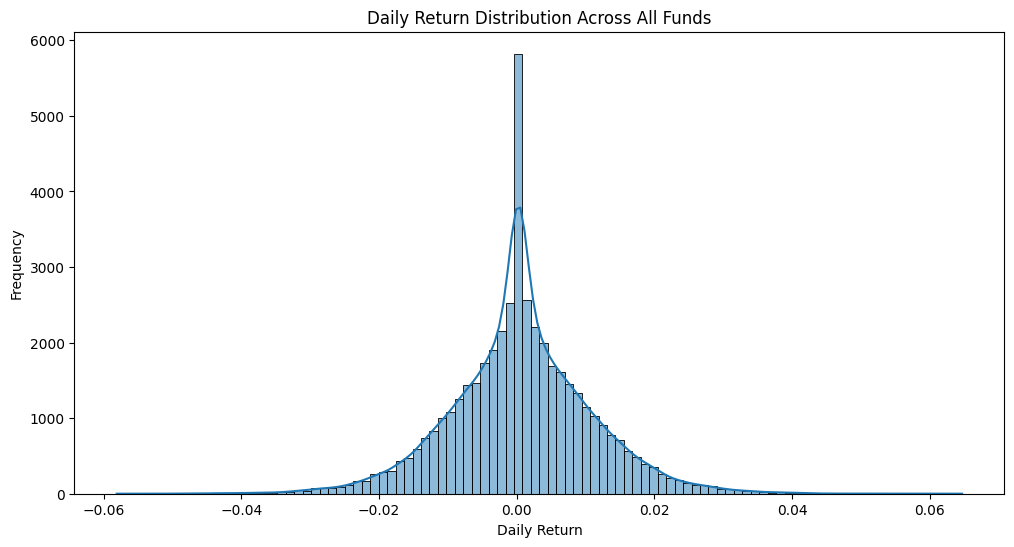

In [29]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=100,
    kde=True
)
plt.title("Daily Return Distribution Across All Funds",)
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

In [32]:
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])


In [36]:
def calculate_cagr(start_nav, end_nav, years):
    return (end_nav / start_nav) ** (1 / years) - 1
cagr_results = []


In [42]:
for fund in nav['amfi_code'].unique():
    fund_data = nav[nav['amfi_code'] == fund].sort_values('date')
    latest_date = fund_data['date'].max()
    latest_nav = fund_data.iloc[-1]['nav']
    row = {'amfi_code': fund}

In [38]:
for years in [1, 3, 5]:
        start_date = latest_date - pd.DateOffset(years=years)
        period_data = fund_data[fund_data['date'] >= start_date]
        if len(period_data) > 0:
            start_nav = period_data.iloc[0]['nav']
            cagr = calculate_cagr(start_nav,latest_nav,years)
            row[f'CAGR_{years}Y'] = cagr * 100
        else:
            row[f'CAGR_{years}Y'] = None

In [43]:
cagr_results.append(row)

In [48]:
cagr_df = pd.DataFrame(cagr_results)

cagr_df.head(40)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336
5,101208,7.236645,6.315784,5.705734
6,102885,20.207704,19.667262,15.878823
7,102886,-16.797481,-0.767406,1.030350
8,102887,13.583135,25.556188,14.678110
9,118632,33.981048,22.652360,20.881118


In [53]:
RF = 0.065
sharpe_results = []
for fund in nav['amfi_code'].unique():
    fund_returns = (nav[nav['amfi_code'] == fund]['daily_return'].dropna())
    annual_return = fund_returns.mean() * 252
    annual_volatility = (fund_returns.std() * np.sqrt(252))
    sharpe_ratio = ((annual_return - RF)/ annual_volatility)
    sharpe_results.append({'amfi_code': fund,'Sharpe_Ratio': sharpe_ratio})
sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df['Sharpe_Rank'] = (sharpe_df['Sharpe_Ratio'].rank(ascending=False))
sharpe_df = sharpe_df.sort_values('Sharpe_Ratio',ascending=False)
print(sharpe_df)

    amfi_code  Sharpe_Ratio  Sharpe_Rank
34     148567      1.448291          1.0
30     120843      1.306744          2.0
36     148569      1.234930          3.0
19     119551      1.208267          4.0
25     120505      1.180101          5.0
38     149323      1.132122          6.0
2      100033      1.093699          7.0
9      118632      1.081659          8.0
3      101206      1.027213          9.0
24     120504      1.026524         10.0
16     119094      0.998231         11.0
20     119552      0.953279         12.0
39     149324      0.949796         13.0
21     119598      0.945308         14.0
35     148568      0.926287         15.0
6      102885      0.817099         16.0
23     120503      0.797973         17.0
32     125497      0.775790         18.0
12     118635      0.664857         19.0
26     120506      0.648879         20.0
10     118633      0.645207         21.0
8      102887      0.619518         22.0
27     120507      0.495723         23.0
28     120841   

In [54]:
RF = 0.065
sortino_results = []
for fund in nav['amfi_code'].unique():
    fund_returns = nav[nav['amfi_code'] == fund]['daily_return'].dropna()
    annual_return = fund_returns.mean() * 252
    downside_std = fund_returns[fund_returns < 0].std() * np.sqrt(252)
    sortino_ratio = (annual_return - RF) / downside_std
    sortino_results.append({'amfi_code': fund, 'Sortino_Ratio': sortino_ratio})
sortino_df = pd.DataFrame(sortino_results)
sortino_df['Sortino_Rank'] = sortino_df['Sortino_Ratio'].rank(ascending=False)
sortino_df = sortino_df.sort_values('Sortino_Ratio', ascending=False)
print(sortino_df)

    amfi_code  Sortino_Ratio  Sortino_Rank
34     148567       2.385644           1.0
30     120843       2.364320           2.0
36     148569       2.146914           3.0
19     119551       2.140267           4.0
25     120505       2.029353           5.0
38     149323       1.875101           6.0
9      118632       1.850133           7.0
2      100033       1.829134           8.0
24     120504       1.805294           9.0
3      101206       1.799563          10.0
16     119094       1.703797          11.0
21     119598       1.675317          12.0
35     148568       1.632741          13.0
39     149324       1.619793          14.0
20     119552       1.609776          15.0
6      102885       1.435742          16.0
23     120503       1.337943          17.0
32     125497       1.330651          18.0
10     118633       1.154476          19.0
12     118635       1.137977          20.0
26     120506       1.095895          21.0
8      102887       1.088755          22.0
27     1205

In [59]:
from scipy.stats import linregress
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])
nifty100 = benchmark[benchmark['index_name'].str.contains('100', case=False, na=False)].copy()
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
alpha_beta_results = []
for fund in nav['amfi_code'].unique():
    fund_returns = nav[nav['amfi_code'] == fund][['date', 'daily_return']].dropna()
    merged = pd.merge(
        fund_returns,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    ).dropna()
    if len(merged) == 0:
        continue
    slope, intercept, r_value, p_value, std_err = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )
    alpha_beta_results.append({
        'amfi_code': fund,
        'Alpha': intercept * 252,
        'Beta': slope
    })
alpha_beta_df = pd.DataFrame(alpha_beta_results)
print(alpha_beta_df)
alpha_beta_df.to_csv("../data/processed/alpha_beta.csv", index=False)

    amfi_code     Alpha      Beta
0      100016  0.037476 -0.058268
1      100025  0.042818  0.001158
2      100033  0.271954  0.005104
3      101206  0.213998  0.021086
4      101207  0.108971 -0.065289
5      101208  0.060861  0.000267
6      102885  0.170488 -0.019487
7      102886  0.028969 -0.042125
8      102887  0.162113  0.016683
9      118632  0.218294 -0.008354
10     118633  0.156438 -0.036639
11     118634  0.175007  0.103497
12     118635  0.151364 -0.001434
13     118636  0.050748  0.001257
14     119092  0.068995  0.009731
15     119093  0.082328  0.025883
16     119094  0.260767 -0.066265
17     119095  0.048016 -0.066951
18     119120  0.056209 -0.006414
19     119551  0.232010 -0.031751
20     119552  0.198686 -0.026159
21     119598  0.303370 -0.023196
22     119599  0.048824  0.062002
23     120503  0.177033 -0.040269
24     120504  0.211948  0.016232
25     120505  0.292636  0.000549
26     120506  0.162539  0.041896
27     120507  0.067462 -0.000444
28     120841 

In [61]:
drawdown_results = []
for fund in nav['amfi_code'].unique():
    fund_data = nav[nav['amfi_code'] == fund].sort_values('date').copy()
    fund_data['running_max'] = fund_data['nav'].cummax()
    fund_data['drawdown'] = (fund_data['nav'] / fund_data['running_max']) - 1
    max_drawdown = fund_data['drawdown'].min()
    trough_idx = fund_data['drawdown'].idxmin()
    trough_date = fund_data.loc[trough_idx, 'date']
    peak_date = fund_data.loc[:trough_idx].iloc[
        fund_data.loc[:trough_idx, 'nav'].idxmax() - fund_data.index[0]]['date']
    drawdown_results.append({
        'amfi_code': fund,
        'Max_Drawdown': max_drawdown,
        'Peak_Date': peak_date,
        'Trough_Date': trough_date
    })
drawdown_df = pd.DataFrame(drawdown_results)
print(drawdown_df)

    amfi_code  Max_Drawdown  Peak_Date Trough_Date
0      100016     -0.247344 2022-03-30  2022-09-15
1      100025     -0.043083 2023-05-23  2023-07-28
2      100033     -0.162172 2022-03-11  2022-05-12
3      101206     -0.112916 2023-04-24  2023-07-05
4      101207     -0.354469 2024-11-21  2026-05-11
5      101208     -0.001622 2023-09-05  2023-09-12
6      102885     -0.108599 2022-02-03  2022-03-29
7      102886     -0.280011 2025-01-07  2026-04-27
8      102887     -0.215398 2022-01-03  2022-07-04
9      118632     -0.174141 2024-01-02  2024-07-19
10     118633     -0.186297 2023-10-30  2024-02-29
11     118634     -0.233449 2025-04-09  2026-02-20
12     118635     -0.116506 2022-01-03  2022-06-09
13     118636     -0.083164 2023-02-09  2024-02-09
14     119092     -0.144016 2023-10-12  2025-02-07
15     119093     -0.217514 2022-02-24  2023-05-22
16     119094     -0.209609 2022-04-14  2022-08-11
17     119095     -0.516778 2025-05-22  2026-05-11
18     119120     -0.043287 202

In [63]:
scorecard_df = cagr_df[['amfi_code', 'CAGR_3Y']].copy()
scorecard_df = scorecard_df.merge(sharpe_df[['amfi_code', 'Sharpe_Ratio']], on='amfi_code')
scorecard_df = scorecard_df.merge(alpha_beta_df[['amfi_code', 'Alpha']], on='amfi_code')
scorecard_df = scorecard_df.merge(perf[['amfi_code', 'expense_ratio_pct']], on='amfi_code')
scorecard_df = scorecard_df.merge(drawdown_df[['amfi_code', 'Max_Drawdown']], on='amfi_code')
scorecard_df['return_rank'] = scorecard_df['CAGR_3Y'].rank(pct=True)
scorecard_df['sharpe_rank'] = scorecard_df['Sharpe_Ratio'].rank(pct=True)
scorecard_df['alpha_rank'] = scorecard_df['Alpha'].rank(pct=True)
scorecard_df['expense_rank'] = (-scorecard_df['expense_ratio_pct']).rank(pct=True)
scorecard_df['dd_rank'] = scorecard_df['Max_Drawdown'].rank(pct=True)
scorecard_df['Fund_Score'] = (
    scorecard_df['return_rank'] * 30 +
    scorecard_df['sharpe_rank'] * 25 +
    scorecard_df['alpha_rank'] * 20 +
    scorecard_df['expense_rank'] * 15 +
    scorecard_df['dd_rank'] * 10
)
scorecard_df = scorecard_df.sort_values('Fund_Score', ascending=False)
scorecard_df['Fund_Rank'] = range(1, len(scorecard_df) + 1)
print(scorecard_df)
scorecard_df.to_csv("../data/processed/fund_scorecard.csv", index=False)

    amfi_code    CAGR_3Y  Sharpe_Ratio     Alpha  expense_ratio_pct  \
34     148567  34.000916      1.448291  0.269838               1.46   
25     120505  31.777537      1.180101  0.292636               1.36   
30     120843  29.582770      1.306744  0.273305               1.45   
2      100033  32.442459      1.093699  0.271954               1.38   
24     120504  32.487429      1.026524  0.211948               0.80   
16     119094  35.111802      0.998231  0.260767               1.38   
19     119551  30.456524      1.208267  0.232010               1.54   
36     148569  29.178902      1.234930  0.282704               1.60   
3      101206  28.967695      1.027213  0.213998               1.60   
21     119598  26.669922      0.945308  0.303370               1.43   
38     149323  26.869991      1.132122  0.265986               1.61   
39     149324  27.000427      0.949796  0.300579               1.52   
9      118632  22.652360      1.081659  0.218294               1.51   
20    

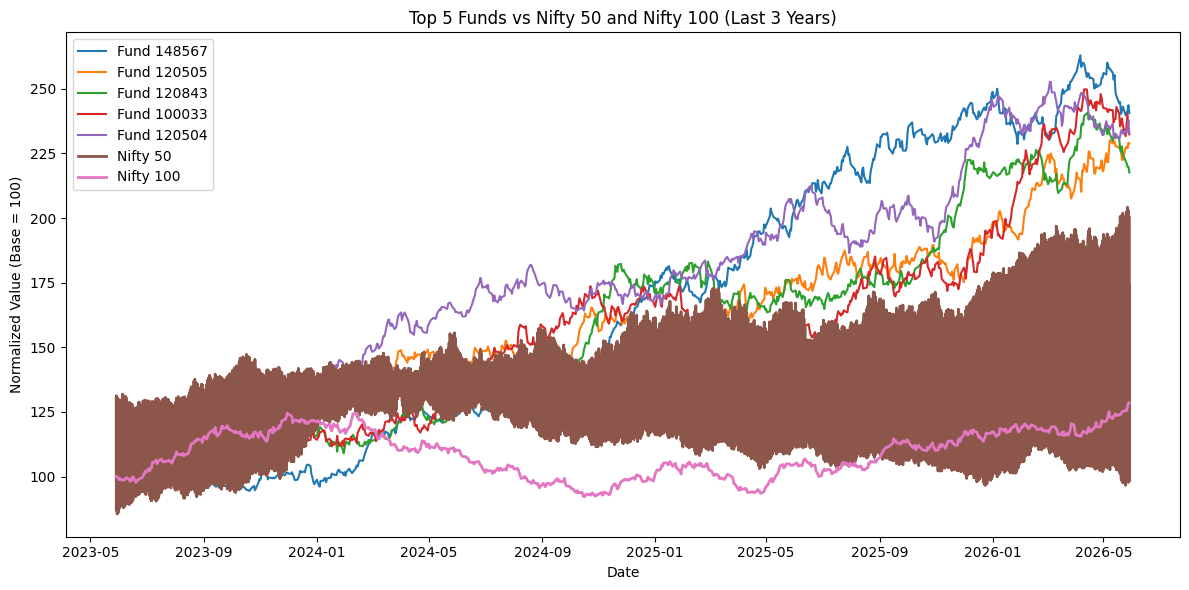

   amfi_code  Tracking_Error
0     148567        0.187974
1     120505        0.232661
2     120843        0.206540
3     100033        0.224976
4     120504        0.187299


In [64]:
top5_funds = scorecard_df.head(5)['amfi_code'].tolist()
benchmark['date'] = pd.to_datetime(benchmark['date'])
nifty50 = benchmark[benchmark['index_name'].str.contains('50', case=False, na=False)].copy()
nifty100 = benchmark[benchmark['index_name'].str.contains('100', case=False, na=False)].copy()
nifty50 = nifty50.sort_values('date')
nifty100 = nifty100.sort_values('date')
end_date = nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)
plt.figure(figsize=(12,6))
for fund in top5_funds:
    fund_data = nav[(nav['amfi_code'] == fund) & (nav['date'] >= start_date)].copy()
    base_nav = fund_data.iloc[0]['nav']
    fund_data['normalized'] = (fund_data['nav'] / base_nav) * 100
    plt.plot(fund_data['date'], fund_data['normalized'], label=f'Fund {fund}')
nifty50 = nifty50[nifty50['date'] >= start_date]
nifty100 = nifty100[nifty100['date'] >= start_date]
nifty50['normalized'] = (nifty50['close_value'] / nifty50.iloc[0]['close_value']) * 100
nifty100['normalized'] = (nifty100['close_value'] / nifty100.iloc[0]['close_value']) * 100
plt.plot(nifty50['date'], nifty50['normalized'], label='Nifty 50', linewidth=2)
plt.plot(nifty100['date'], nifty100['normalized'], label='Nifty 100', linewidth=2)
plt.title('Top 5 Funds vs Nifty 50 and Nifty 100 (Last 3 Years)')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base = 100)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
tracking_error_results = []
for fund in top5_funds:
    fund_returns = nav[nav['amfi_code'] == fund][['date', 'daily_return']].dropna()
    merged = pd.merge(
        fund_returns,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    ).dropna()
    tracking_error = (
        (merged['daily_return'] - merged['benchmark_return']).std()
        * np.sqrt(252)
    )
    tracking_error_results.append({
        'amfi_code': fund,
        'Tracking_Error': tracking_error
    })
tracking_error_df = pd.DataFrame(tracking_error_results)
print(tracking_error_df)
